# Repeated softmaxification

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

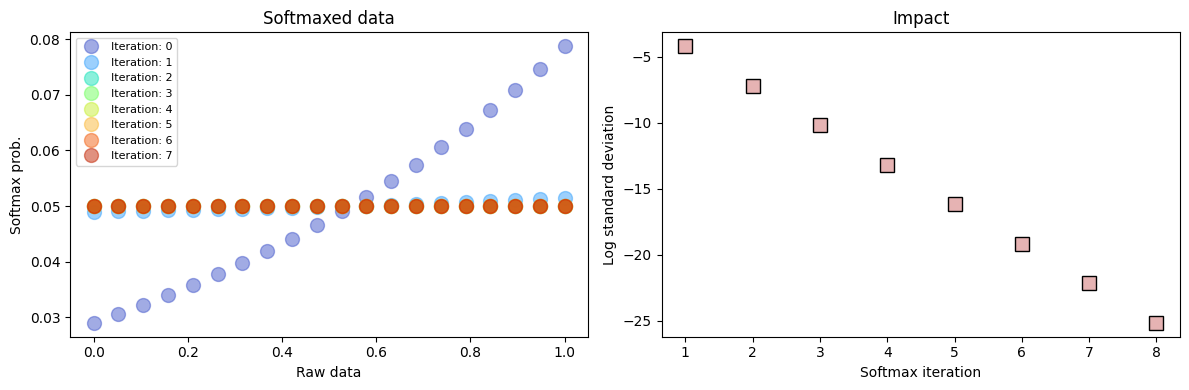

In [3]:
x = np.linspace(0,1,20)
u = np.exp(x) / np.sum(np.exp(x))

num_repeats = 8
u_std = np.zeros(num_repeats)

# colors for the dots
colors = plt.cm.turbo(np.linspace(.1, .9, num_repeats))

_, axs = plt.subplots(1,2,figsize = (12,4))
for r in range(num_repeats):

  # plot the pdist
  axs[0].plot(x, u, 'o', color = colors[r], markerfacecolor = colors[r], label = f'Iteration: {r}', alpha = .5, markersize = 10)

  # get the std
  u_std[r] = np.std(u)

  # re-calculate softmax
  u = np.exp(u) / np.sum(np.exp(u))

axs[1].plot(range(1,num_repeats + 1), np.log(u_std), 'ks', markerfacecolor = [.9,.7,.7], markersize = 10)
axs[1].set(xlabel = 'Softmax iteration', ylabel = 'Log standard deviation', title = 'Impact')

axs[0].legend(fontsize = 8)
axs[0].set(xlabel = 'Raw data', ylabel = 'Softmax prob.', title = 'Softmaxed data')

plt.tight_layout()
plt.show()

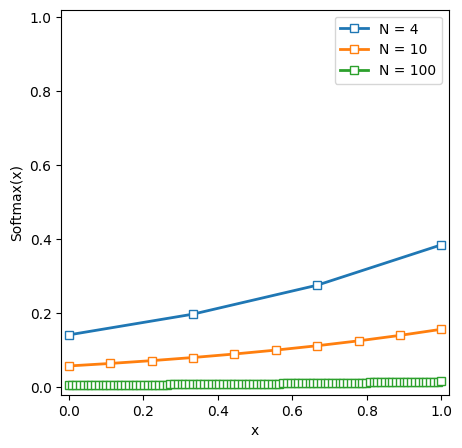

In [4]:
# why repeated softmax supresses variability

N = [4,10,100]

plt.figure(figsize = (5,5))

for n in N:

  # the data (e.g., token logits)
  x = np.linspace(0,1,n)

  # sofmtax the data
  smx = np.exp(x) / np.exp(x).sum()

  # plot
  plt.plot(x, smx, '-s', linewidth = 2, markerfacecolor = 'w', label = f'N = {n}')

plt.legend()
plt.gca().set(xlim=[-.02,1.02], ylim = [-.02, 1.02], xlabel = 'x', ylabel = "Softmax(x)")
plt.show()

# Impact of range and temperature on softmax

/tmp/ipykernel_9044/1393553475.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  a.legend(loc='upper left')
/tmp/ipykernel_9044/1393553475.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  a.legend(loc='upper left')


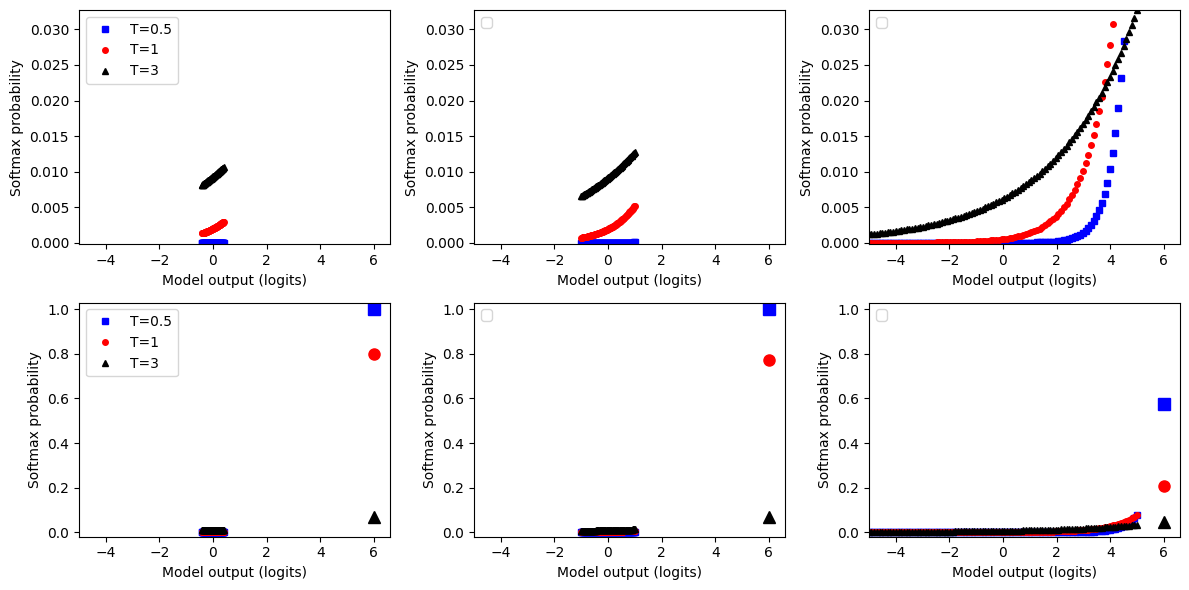

In [11]:
import torch
import matplotlib.pyplot as plt

temps  = [.5, 1, 3]
bounds = [.4, 1, 5]

colors = 'brk'
shapes = 'so^'

_, axs = plt.subplots(2, 3, figsize=(12, 6))

for bndi in range(3):

    logits = torch.linspace(-bounds[bndi], bounds[bndi], 100)
    logits = torch.cat((logits, torch.tensor([6.])))

    for ti in range(3):

        T = temps[ti]
        sm = torch.exp(logits / T) / torch.exp(logits / T).sum()

        for ii in range(2):

            axs[ii, bndi].plot(
                logits[:-1],
                sm[:-1],
                linestyle='none',
                marker=shapes[ti],
                markerfacecolor=colors[ti],
                markeredgecolor=colors[ti],
                markersize=4,
                label=f'T={T}' if bndi == 0 else None
            )

            axs[ii, bndi].plot(
                logits[-1],
                sm[-1],
                linestyle='none',
                marker=shapes[ti],
                markerfacecolor=colors[ti],
                markeredgecolor=colors[ti],
                markersize=8
            )

# axis settings for top-row graphs to highlight the impact on smaller values
for a in axs[0, :]:
    a.set(
        xlim=[-bounds[-1], 6.6],
        ylim=[-.0002, sm[-2]],
        xlabel='Model output (logits)',
        ylabel='Softmax probability'
    )
    a.legend(loc='upper left')

# axis settings for bottom-row graphs to show probs up to 1
for a in axs[1, :]:
    a.set(
        xlim=[-bounds[-1], 6.6],
        ylim=[-.02, 1.03],
        xlabel='Model output (logits)',
        ylabel='Softmax probability'
    )
    a.legend(loc='upper left')

plt.tight_layout()
plt.show()